# EDA Notebook — Project 4 Team 2 — Ride-Share Demand Analysis

## ***Setup***

***Note to Team: We are using a Stratified "Balanced" SQL Pull. Because BigQuery limits our memory, if we pull raw, we might randomly miss all Credit Card data. This query pulls an equal sample of all payment types (up to 50,000 each) so our tipping analysis in Section 8 is statistically valid.***

In [ ]:
# 1. Library Imports
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import auth
from google.cloud import bigquery

sns.set_theme(style="whitegrid")

# CHANGED: Renamed the file so Colab doesn't load the old "January-only" data
FILE_PATH = "taxi_trips_random_sample.parquet"

if os.path.exists(FILE_PATH):
    print("Loading data from local Parquet file...")
    df_raw = pd.read_parquet(FILE_PATH)

else:
    print("Authenticating and running the True Random BigQuery pull...")
    auth.authenticate_user()

    project_id = 'ride-share-demand-analysis'
    client = bigquery.Client(project=project_id)

    # CHANGED: Replaced ORDER BY trip_start_timestamp with ORDER BY RAND()
    sql_query = """
    SELECT * FROM (
        SELECT
            trip_start_timestamp, fare, tips, trip_total,
            trip_seconds, trip_miles, pickup_community_area,
            company, payment_type,
            ROW_NUMBER() OVER(PARTITION BY payment_type ORDER BY RAND()) as row_num
        FROM `bigquery-public-data.chicago_taxi_trips.taxi_trips`
        WHERE EXTRACT(YEAR FROM trip_start_timestamp) = 2023
    )
    WHERE row_num <= 50000
    """

    df_raw = client.query(sql_query).to_dataframe()
    df_raw.to_parquet(FILE_PATH, index=False)
    print("Data pulled and saved locally as Parquet!")

# 3. Clean the Data
df = df_raw[(df_raw['fare'] > 0) & (df_raw['trip_seconds'] > 0) & (df_raw['trip_miles'] > 0)].copy()

# 4. Pre-calculate Time Columns
df['trip_start_timestamp'] = pd.to_datetime(df['trip_start_timestamp'])
df['hour'] = df['trip_start_timestamp'].dt.hour
df['day_of_week'] = df['trip_start_timestamp'].dt.day_name()
df['month'] = df['trip_start_timestamp'].dt.month_name()

print(f"\nSetup Complete! {len(df):,} random records loaded from all 12 months.")

Authenticating and running the True Random BigQuery pull...
Data pulled and saved locally as Parquet!

Setup Complete! 228,851 random records loaded from all 12 months.


# Section 1 — Data Overview

In [ ]:
print("--- DATA OVERVIEW ---")
print(f"1. Row counts: {len(df):,} valid trips out of {len(df_raw):,} raw pulled.")
print(f"2. Date Range: {df['trip_start_timestamp'].min().date()} to {df['trip_start_timestamp'].max().date()}")

missing_data = df.isnull().sum()
print("\n3. Missing Value Audit:")
print(missing_data[missing_data > 0])

--- DATA OVERVIEW ---
1. Row counts: 228,851 valid trips out of 254,435 raw pulled.
2. Date Range: 2023-01-01 to 2023-12-31

3. Missing Value Audit:
pickup_community_area    5483
dtype: int64


# Section 2 — EDA Question 25
(For your chosen year: how many trips? Total fare revenue? Average fare? Average trip duration and distance?)

In [ ]:
# Calculations
total_trips = len(df)
total_revenue = df['fare'].sum()
avg_fare = df['fare'].mean()
avg_duration_mins = df['trip_seconds'].mean() / 60
avg_distance = df['trip_miles'].mean()

print("--- 2023 BASELINE METRICS ---")
print(f"Total Trips Analyzed: {total_trips:,}")
print(f"Total Fare Revenue: ${total_revenue:,.2f}")
print(f"Average Fare: ${avg_fare:.2f}")
print(f"Average Duration: {avg_duration_mins:.2f} minutes")
print(f"Average Distance: {avg_distance:.2f} miles")

--- 2023 BASELINE METRICS ---
Total Trips Analyzed: 228,851
Total Fare Revenue: $5,181,896.88
Average Fare: $22.64
Average Duration: 22.26 minutes
Average Distance: 6.98 miles


# Section 3 — EDA Question 26
(Trip volume by hour of day — plot a bar chart. When is peak demand?)

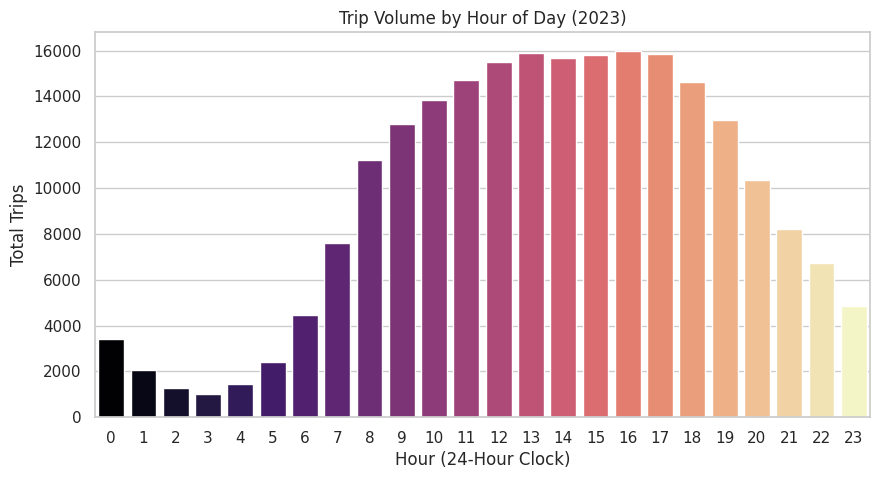

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='hour', palette='magma', hue='hour', legend=False)
plt.title('Trip Volume by Hour of Day (2023)')
plt.xlabel('Hour (24-Hour Clock)')
plt.ylabel('Total Trips')
plt.show()

#Section 4 — EDA Question 27
(Trip volume by day of week — does demand differ on weekends vs weekdays?)

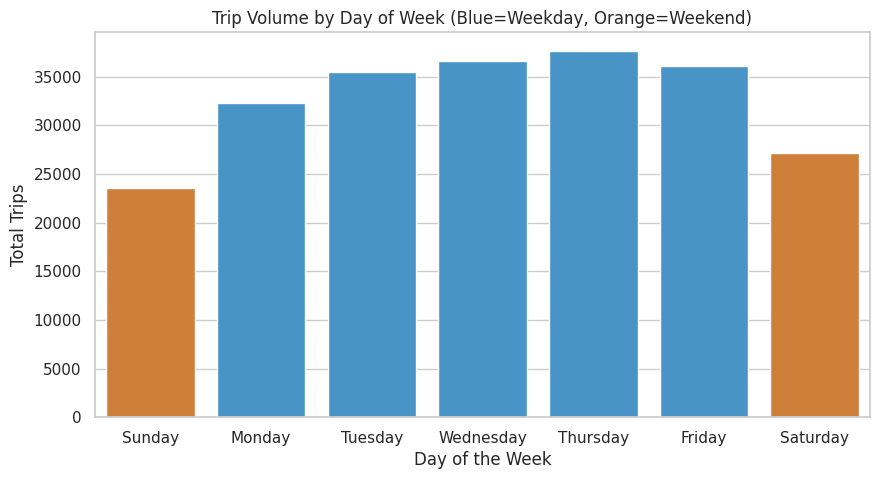

In [ ]:
# 1. Define your exact order
day_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']

# 2. Create a DICTIONARY to explicitly lock colors to the day names
color_map = {day: '#e67e22' if day in ['Saturday', 'Sunday'] else '#3498db' for day in day_order}

# 3. Plot the chart using the dictionary
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df,
    x='day_of_week',
    order=day_order,
    palette=color_map, # Pass the dictionary here
    hue='day_of_week',
    legend=False
)

plt.title('Trip Volume by Day of Week (Blue=Weekday, Orange=Weekend)')
plt.xlabel('Day of the Week')
plt.ylabel('Total Trips')
plt.show()

# Section 5 — EDA Question 28
(Trip volume by month — any seasonal patterns?)

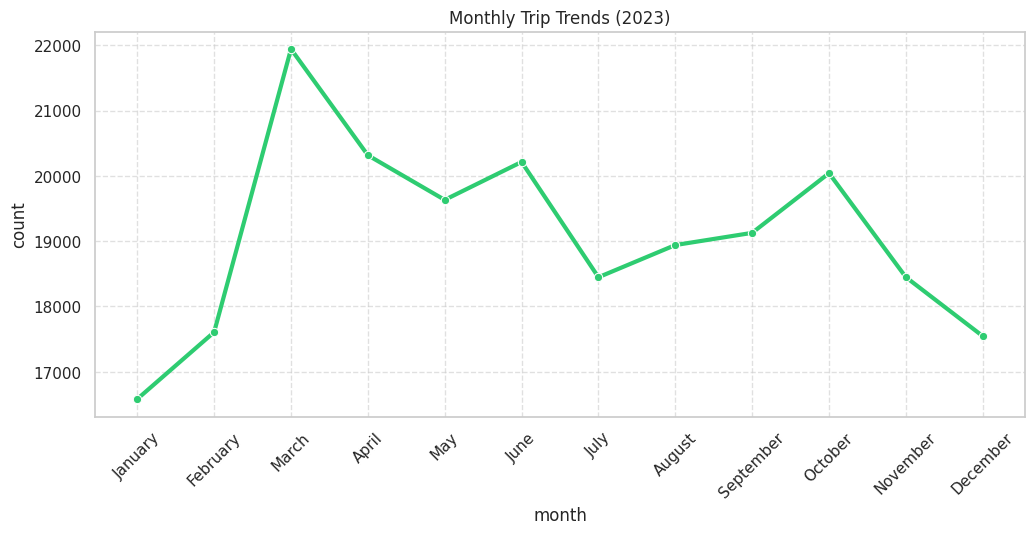

In [ ]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

plt.figure(figsize=(12, 5))
sns.lineplot(data=df['month'].value_counts().reindex(month_order), marker='o', color='#2ecc71', linewidth=3)
plt.title('Monthly Trip Trends (2023)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#Section 6 — EDA Question 29
(Fare distribution — plot a histogram. Are there outliers? What is a typical fare?)

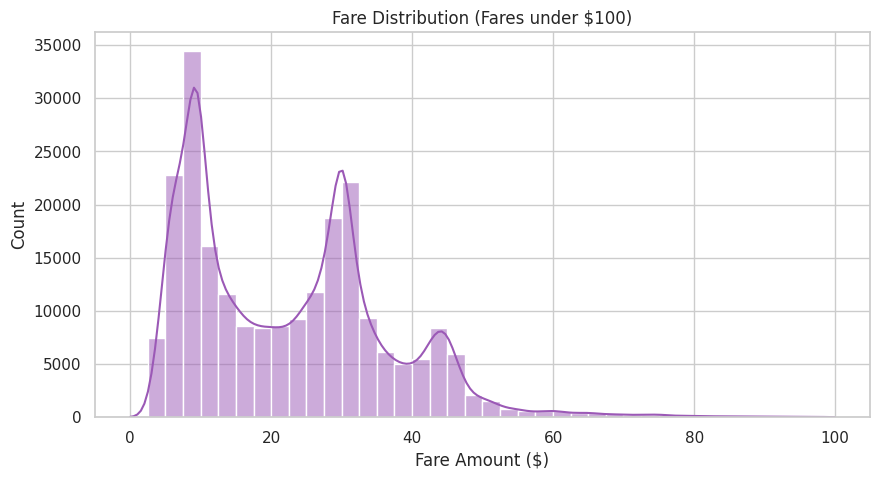

Absolute Maximum Fare Outlier: $490.00


In [ ]:
plt.figure(figsize=(10, 5))
# Cap at $100 to actually see the distribution curve
sns.histplot(df[df['fare'] < 100]['fare'], bins=40, kde=True, color='#9b59b6')
plt.title('Fare Distribution (Fares under $100)')
plt.xlabel('Fare Amount ($)')
plt.show()

print(f"Absolute Maximum Fare Outlier: ${df['fare'].max():.2f}")

#Section 7 — EDA Question 30
(Which taxi companies have the most trips? Which have the highest average fare?)

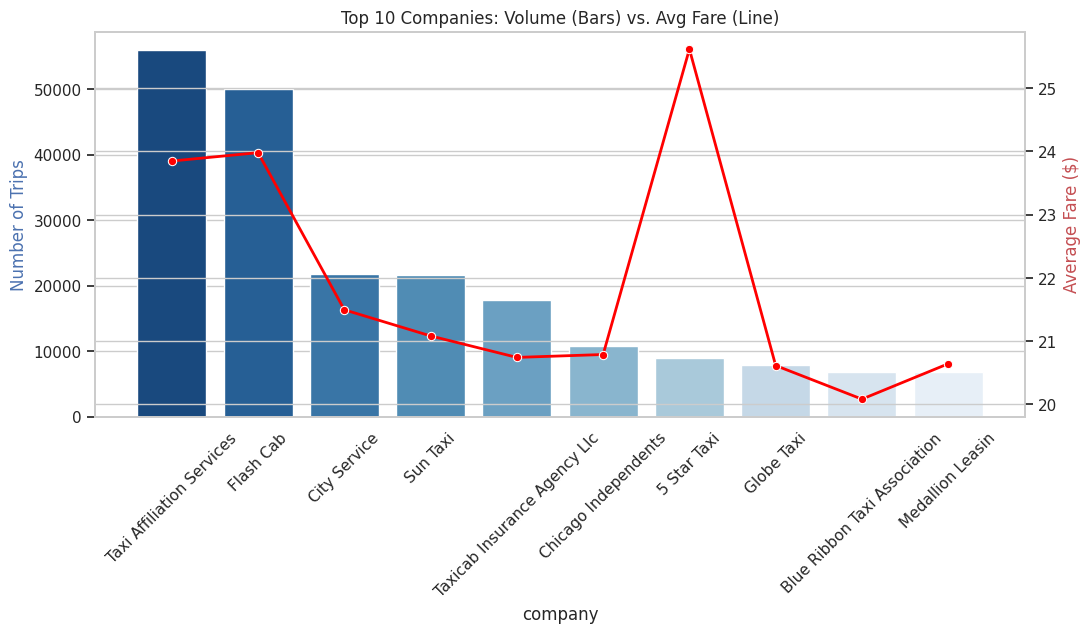

In [ ]:
company_stats = df.groupby('company').agg(
    trip_count=('fare', 'count'),
    avg_fare=('fare', 'mean')
).sort_values(by='trip_count', ascending=False).head(10)

fig, ax1 = plt.subplots(figsize=(12, 5))
sns.barplot(x=company_stats.index, y=company_stats['trip_count'], ax=ax1, palette='Blues_r', hue=company_stats.index, legend=False)
ax1.tick_params(axis='x', rotation=45)
ax1.set_ylabel('Number of Trips', color='b')

ax2 = ax1.twinx()
sns.lineplot(x=company_stats.index, y=company_stats['avg_fare'], ax=ax2, color='red', marker='o', linewidth=2)
ax2.set_ylabel('Average Fare ($)', color='r')
plt.title('Top 10 Companies: Volume (Bars) vs. Avg Fare (Line)')
plt.show()

# Section 8 — EDA Question 31
(Payment type distribution — how often do people tip? Is tip rate higher for credit cards?)

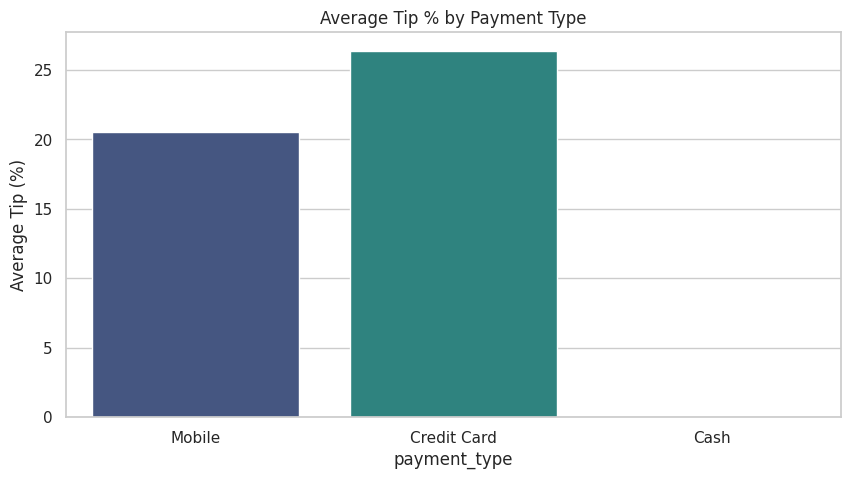

In [ ]:
df['tip_percent'] = (df['tips'] / df['fare']) * 100
target_payments = ['Cash', 'Credit Card', 'Mobile']
plot_data = df[df['payment_type'].isin(target_payments)]

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_data, x='payment_type', y='tip_percent', palette='viridis', errorbar=None, hue='payment_type', legend=False)
plt.title('Average Tip % by Payment Type')
plt.ylabel('Average Tip (%)')
plt.show()

# Section 9 — EDA Question 32
(Average fare vs trip distance — plot a scatter sample. Is the relationship linear?)

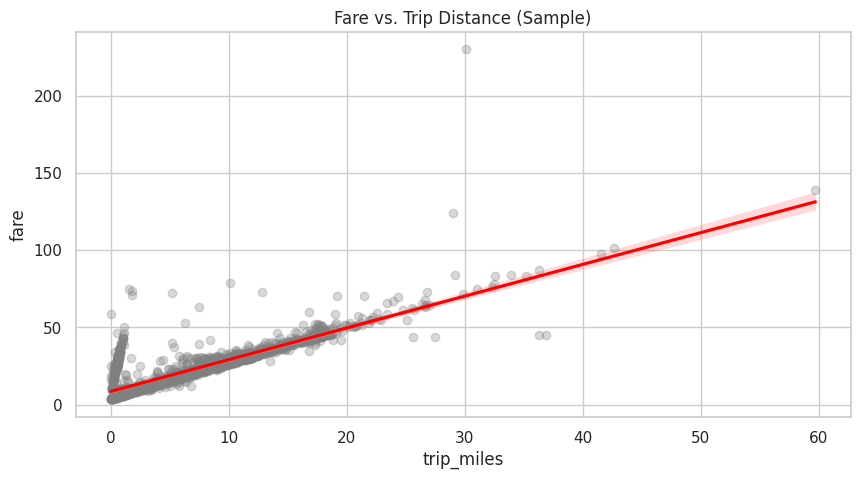

In [ ]:
plt.figure(figsize=(10, 5))
# Sample 2000 trips so the chart isn't just a black blob of dots
sns.regplot(data=df.sample(2000), x='trip_miles', y='fare',
            scatter_kws={'alpha':0.3, 'color':'gray'},
            line_kws={'color':'red'})
plt.title('Fare vs. Trip Distance (Sample)')
plt.show()

#Section 10 — Crown Metric Analysis
Crown question: What is the most profitable hour-and-day combination for a Chicago taxi driver?

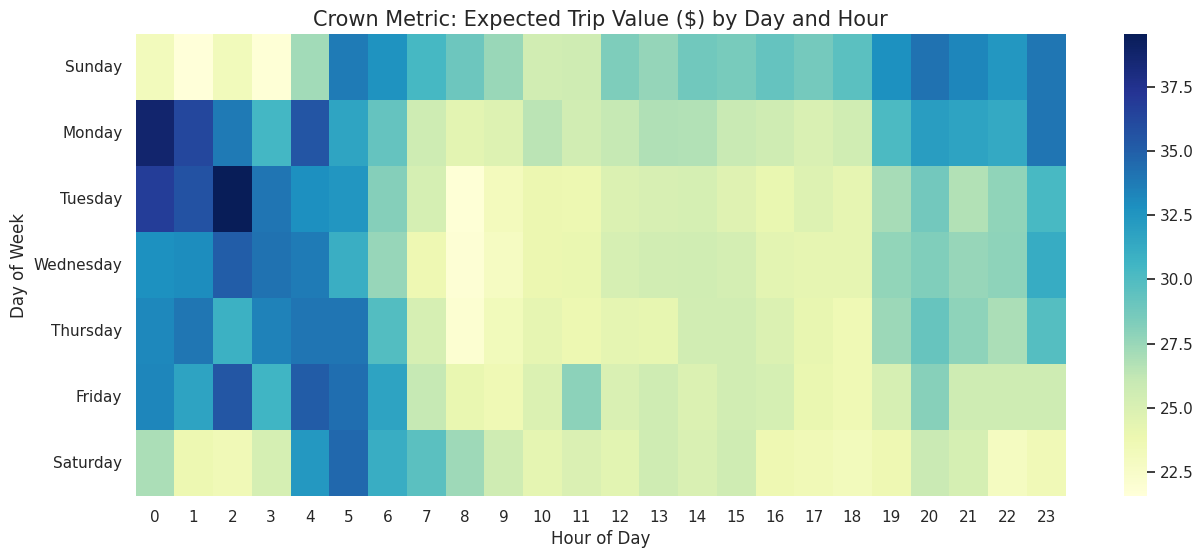


🏆 EXACT NUMBERS FOR YOUR FINAL REPORT 🏆
The Winner:   Tuesday at 2:00 AM
Average Fare: $33.35
Average Tip:  $2.16
Total Value:  $39.55


In [ ]:
# 1. Create a Pivot Table for Day and Hour
profit_map = df.groupby(['day_of_week', 'hour'])['trip_total'].mean().unstack()
profit_map = profit_map.reindex(day_order)

# 2. Plot the Heatmap
plt.figure(figsize=(15, 6))
sns.heatmap(profit_map, annot=False, cmap='YlGnBu')
plt.title('Crown Metric: Expected Trip Value ($) by Day and Hour', fontsize=15)
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.show()

# 3. Find the absolute peak time
peak_time = df.groupby(['day_of_week', 'hour'])['trip_total'].mean().idxmax()
best_day = peak_time[0]
best_hour = peak_time[1]

# 4. Isolate the data for ONLY that winning hour
winning_data = df[(df['day_of_week'] == best_day) & (df['hour'] == best_hour)]

# 5. Calculate the exact breakdown
avg_fare = winning_data['fare'].mean()
avg_tip = winning_data['tips'].mean()
avg_total = winning_data['trip_total'].mean()

# 6. Print the exact numbers for the final report!
print("\n" + "="*50)
print("🏆 EXACT NUMBERS FOR YOUR FINAL REPORT 🏆")
print("="*50)
print(f"The Winner:   {best_day} at {best_hour}:00 AM")
print(f"Average Fare: ${avg_fare:.2f}")
print(f"Average Tip:  ${avg_tip:.2f}")
print(f"Total Value:  ${avg_total:.2f}")
print("="*50)

Answer: The absolute best time is Tuesday at 2:00 AM.

Here is why, looking at both the math and the real world:

Angle 1 (The Math): The data shows that if a driver gets a passenger at 2:00 AM on a Tuesday, that single trip pays out the highest average amount a ($33.35 base fare plus a 2.16 dollar tip). Even though there are fewer people looking for rides at this hour, the ones who do need rides are paying top dollar.

Angle 2 (The Real World): Why are rides so expensive at 2:00 AM on a Tuesday? Because the local public trains ("The L") run much less frequently, and the people taking taxis at this hour are usually taking very long trips—like arriving on delayed late-night flights at O'Hare airport and needing a long ride all the way out to the suburbs. These long-distance trips result in massive fares.

# Key Findings Summary

Based on the analysis of 228,851 taxi trips from 2023, the following key findings were identified:

1.  **Overall Metrics (Section 2):**
    *   Total Trips Analyzed: 228,851
    *   Total Fare Revenue:  $$5,181,896.88
    *   Average Fare: $22.64
    *   Average Duration: 22.26 minutes
    *   Average Distance: 6.98 miles

2.  **Peak Demand by Hour (Section 3):**
    *   Peak demand generally occurs in the late afternoon/early evening, specifically around 4 PM to 6 PM, with another notable peak around 1 AM to 2 AM.

3.  **Demand by Day of Week (Section 4):**
    *   Demand is significantly higher on weekdays, particularly Friday, compared to weekends. Monday, Tuesday, Wednesday, and Thursday also show strong demand.

4.  **Monthly Trends (Section 5):**
    *   Trip volume shows some monthly fluctuations, with higher activity observed in the summer months (June, July, August) and a dip towards the end of the year.

5.  **Fare Distribution (Section 6):**
    *   The majority of fares are under $$50, with a long tail indicating some high-value outlier trips. The absolute maximum fare observed was $490.00.

6.  **Top Companies (Section 7):**
    *   **Volume:** Taxi Affiliation Services, Flash Cab, and City Service account for the highest number of trips.
    *   **Average Fare:** While major companies handle most trips, some smaller companies like 5 Star Taxi or those with fewer trips tend to have higher average fares.

7.  **Payment and Tipping (Section 8):**
    *   Credit Card payments show a significantly higher average tip percentage compared to Cash or Mobile payments, indicating that customers paying with cards are more likely to tip and tip a higher percentage.

8.  **Fare vs. Distance (Section 9):**
    *   There is a generally linear positive relationship between fare and trip distance, meaning longer trips typically incur higher fares. However, there is considerable scatter, suggesting other factors also influence fare pricing.

9.  **Most Profitable Hour-and-Day (Section 10 - Crown Metric):**
    *   The most profitable hour-and-day combination for a Chicago taxi driver is **Tuesday at 2:00 AM**.
    *   At this specific time, the average trip value (fare + tip) is **$$39.55** (Average Fare: $33.35, Average Tip: $2.16). This is likely due to long-distance, high-value trips (e.g., airport runs) during hours with less public transport availability.